# Lesson 12 - Analyze tool data with Code Interpreter

**Level:** intermediate | **Demo time:** 8 minutes

This notebook demonstrates one Foundry-backed agent using two tools:

```text
user -> agent -> CSV data tool -> Code Interpreter -> analysis + chart
```

The local function returns sales data as CSV. The agent passes that data to Code Interpreter, which calculates metrics and creates a graph.

## Connect to Foundry

Code Interpreter runs Python in a Foundry-managed sandbox. It may incur additional usage charges.

In [1]:
from agent_framework import Agent, SupportsCodeInterpreterTool
from IPython.display import Image, Markdown, display

from maf_foundry_hackathon.config import (
    WorkshopSettings,
    create_chat_client,
    create_credential,
)

settings = WorkshopSettings.from_env()
credential = create_credential()
chat_client = create_chat_client(settings, credential)

if not isinstance(chat_client, SupportsCodeInterpreterTool):
    raise RuntimeError("The configured chat client does not support Code Interpreter.")

## Create a data tool

In a real application, this function could query a database or API. The demo returns fixed CSV data so its result is safe and repeatable.

In [2]:
def get_monthly_sales() -> str:
    """Return Contoso monthly sales data as CSV."""
    return """month,revenue
January,120000
February,135000
March,128000
April,160000
May,175000
June,190000"""

## Create the agent

The instructions require the agent to retrieve the CSV before using Code Interpreter. Both tools are available during the same agent run.

In [3]:
sales_agent = Agent(
    client=chat_client,
    name="sales_analyst",
    instructions=(
        "Always call get_monthly_sales to obtain the data. Then use Code Interpreter to parse "
        "the returned CSV, calculate total revenue and month-over-month changes, and create a "
        "labeled monthly revenue line chart. Save the chart as a PNG and summarize the main trend."
    ),
    tools=[
        get_monthly_sales,
        chat_client.get_code_interpreter_tool(),
    ],
)

## Run the analysis

One agent call retrieves the CSV, runs the analysis, and generates the graph.

In [4]:
response = await sales_agent.run(
    "Analyze the monthly sales data and show me the trend as a graph."
)

display(Markdown(response.text))

I've parsed the sales data, calculated totals and month-over-month changes, and created a labeled monthly revenue chart.

Key numbers
- Total revenue (Jan–Jun): $908,000
- Notable month-over-month changes:
  - Feb vs Jan: +12.5%
  - Mar vs Feb: -5.2% (small dip)
  - Apr vs Mar: +25.0% (large rebound)
  - May vs Apr: +9.4%
  - Jun vs May: +8.6%

Main trend (summary)
- Overall strong upward trend from January through June after a small dip in March. The largest increase occurred in April (about +25%), and growth continued in May and June at single-digit rates.

Files
- Chart (PNG): [Download the monthly revenue chart](sandbox:/mnt/data/monthly_revenue.png)
- Processed summary CSV: [Download the monthly summary CSV](sandbox:/mnt/data/monthly_revenue_summary.csv)

If you want, I can:
- Add a trendline or forecast,
- Show the table inline in a different format,
- Break down revenue per product or region (if you provide that data).

## Display the generated graph

Code Interpreter stores generated files in its temporary container. The response annotation identifies the PNG so the notebook can download and display it.

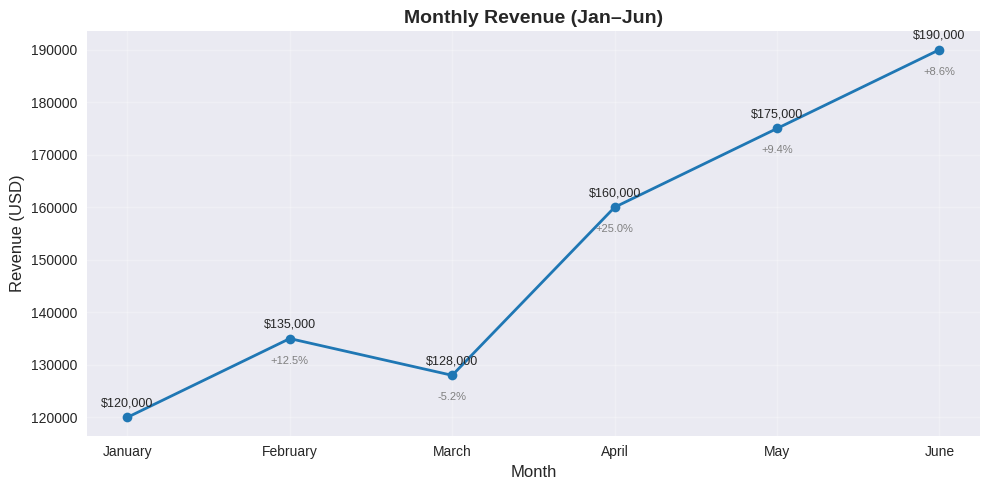

In [5]:
chart_annotation = next(
    (
        annotation
        for message in response.messages
        for content in message.contents
        for annotation in (content.annotations or [])
        if annotation.get("file_id")
        and annotation.get("url", "").lower().endswith(".png")
        and annotation.get("additional_properties", {}).get("container_id")
    ),
    None,
)

if chart_annotation is None:
    raise RuntimeError("Code Interpreter did not return a PNG chart.")

chart_content = await chat_client.client.containers.files.content.retrieve(
    file_id=chart_annotation["file_id"],
    container_id=chart_annotation["additional_properties"]["container_id"],
)
chart_bytes = chart_content.content
await chart_content.aclose()

display(Image(data=chart_bytes))

## Recap

The agent completed the full tool chain in one run:

1. `get_monthly_sales` returned CSV data.
2. Code Interpreter parsed and analyzed that data.
3. Code Interpreter generated a PNG graph.
4. The agent summarized the results and the notebook displayed the graph.

The Code Interpreter container is temporary. Persist important generated files in application-owned storage.

In [ ]:
credential.close()